In [1]:
import numpy as np
import pandas as pd

# Definir as variáveis de caminho
DATADIR = 'C:/Users/Usuário/Downloads/machineLearning/dataset/'
TABLEDIR = DATADIR+'data_tests.csv'
IMAGEDIR = DATADIR+'images'

# Ler os valores tabulares
df = pd.read_csv(TABLEDIR)
# Verificar o número total de entradas
print("O número total de entradas é: ", df.shape[0], "\n")
# Verificar celulas vazias na tabela
print("O número de células vazias por coluna é: \n", df.isnull().sum())

O número total de entradas é:  33126 

O número de células vazias por coluna é: 
 image_name                         4
patient_id                         0
sex                               65
age_approx                        68
anatom_site_general_challenge    527
diagnosis                          0
benign_malignant                   0
target                             0
dtype: int64


In [2]:
# Como podemos ver, algumas das células não possuem valor. A coluna com a maior concentração de células vazias é anatom_site_general_challenge
# A quantidade de células vazias corresponde a 1.59% das entradas.
uniqueAnatom = df["anatom_site_general_challenge"].value_counts(dropna=False)
print(uniqueAnatom, "\n")

# Para não perdermos amostras, as células vazias categóricas (anatom e sex) serão preenchidas como 'unknown', enquanto as células vazias contínuas (age) serão preemchidas com a média
mean_age = df["age_approx"].mean()
df["age_approx"] = df["age_approx"].fillna(mean_age)
df = (df.fillna("unknown"))
print("O número de células vazias por coluna é: \n", df.isnull().sum())

anatom_site_general_challenge
torso              16845
lower extremity     8417
upper extremity     4983
head/neck           1855
NaN                  527
palms/soles          375
oral/genital         124
Name: count, dtype: int64 

O número de células vazias por coluna é: 
 image_name                       0
patient_id                       0
sex                              0
age_approx                       0
anatom_site_general_challenge    0
diagnosis                        0
benign_malignant                 0
target                           0
dtype: int64


In [3]:
# Podemos notar que algumas colunas possuem valores de texto, então iremos mapear 
# Originalmente usava o LabelEncoder mas depois de pesquisar mais, descobri que o OneHotEncoder é melhor nesse caso.
# As colunas 'diagnosis' e 'benign_malignant' não vão ser codificadas, pois elas podem causar vazamento de dados

from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse_output=False)

encoded = encoder.fit_transform(df[['anatom_site_general_challenge']])
encoded_df = pd.DataFrame(encoded, columns=encoder.get_feature_names_out(['anatom_site_general_challenge']), index=df.index)
df = pd.concat([df.drop(columns=['anatom_site_general_challenge']), encoded_df], axis=1)

encoded = encoder.fit_transform(df[['sex']])
encoded_df = pd.DataFrame(encoded, columns=encoder.get_feature_names_out(['sex']), index=df.index)
df = pd.concat([df.drop(columns=['sex']), encoded_df], axis=1)

In [4]:
# Agora vamos iniciar o pre-processamento das imagens
# Primeiro vamos criar uma nova coluna "caminho_imagem" para definir onde a imagem atrelada aquela entrada se encontra
import os

df["caminho_imagem"] = df["image_name"].apply(lambda x: os.path.join(IMAGEDIR, f"{x}.jpg"))
df["caminho_imagem"] = df["caminho_imagem"].str.replace("\\", "/", regex=False)
print(df[["image_name", "caminho_imagem"]].head())


# Agora vamos verificar se todas as entradas possuem uma imagem relacionada
df["existe"] = df["caminho_imagem"].apply(os.path.exists)
print("\n", df["existe"].value_counts())
# Se uma entrada não possuir imagem, ela será removida
df = df[df["existe"]].copy()
print(df.shape)


     image_name                                     caminho_imagem
0       unknown  C:/Users/Usuário/Downloads/machineLearning/dat...
1       unknown  C:/Users/Usuário/Downloads/machineLearning/dat...
2  ISIC_0052212  C:/Users/Usuário/Downloads/machineLearning/dat...
3       unknown  C:/Users/Usuário/Downloads/machineLearning/dat...
4  ISIC_0074268  C:/Users/Usuário/Downloads/machineLearning/dat...

 existe
True     33122
False        4
Name: count, dtype: int64
(33122, 18)


In [5]:
# Agora que nós consolidamos a lista de imagens que serão usadas, nós precisamos fazer o pré-processamento delas
# Nós iremos extrair características das imagens e colocar em um array

from PIL import Image
import cv2
from skimage.feature import graycomatrix, graycoprops
from skimage.measure import shannon_entropy

# nota: Inicialmente eu só estraí quatro características (entropia, bordas, contraste e homogeneidade) mas elas não eram relevantes o suficiente, então preciso melhorar.
img_array = []
for file in df["caminho_imagem"]:
    img = Image.open(file).convert("L")
    img_np = np.array(img)
    # Entropy
    entropy = shannon_entropy(img_np)
    # Edges
    edges = cv2.Canny(img_np, 100, 200)
    # Edge density
    edge_density = np.sum(edges > 0) / edges.size
    # Texture
    glcm = graycomatrix(
        img_np,
        distances=[1],
        angles=[0],
        levels=256,
        symmetric=True,
        normed=True
    )
    # contrast
    contrast = graycoprops(glcm, 'contrast')[0, 0]
    # Homogeneity
    homogeneity = graycoprops(glcm, 'homogeneity')[0, 0]
    img_array.append([entropy,edge_density,contrast,homogeneity])

# Agora iremos transformar esse array em um data frame
df2 = pd.DataFrame(img_array, columns=['entropy','edge_density','contrast','homogeneity'])




In [6]:
# Agora iremos concatenar nossos dois data frames (dados tabulares originais e dados extraídos das imagens)
df3 = pd.concat([df, df2], axis=1)

In [7]:
# Ultima verificação para ver se tem valores nulos ainda
# print(df3.isnull().sum())
# remover nulos
df3 = df3.dropna()

In [8]:
# Verificar se os dados estão balanceados
print(df3["target"].value_counts())
print(df3["target"].value_counts(normalize=True) * 100)

target
0.0    32534
1.0      584
Name: count, dtype: int64
target
0.0    98.236608
1.0     1.763392
Name: proportion, dtype: float64


In [9]:
# Agora vamos iniciar o treinamento
# Primeiro vamos definir os dados de entrada e o objetivo
# nota: eu estava tendo overffiting por causa da coluna 'diagnosis', estava acontecendo um "vazxamento de dados"
X = df3.drop(columns=["image_name","patient_id","caminho_imagem","existe","benign_malignant", "target", "diagnosis"])
y = df3["target"]

# Agora, vamos separar os conjuntos de treino, validação e teste
from sklearn.model_selection import train_test_split

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=0.2,
    stratify=y_train_val,
    random_state=42
)

In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

In [11]:
# Como vimos anteriormente, os dados estão desbalenceados, então iremos aplicar SMOTE
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(
    X_train,
    y_train
)

In [12]:
import keras

model = keras.Sequential([
    keras.layers.Input(shape=(15,)),
    keras.layers.Dense(36, activation="relu"),
    keras.layers.Dense(18, activation="relu"),
    keras.layers.Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 36)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 18)             │           666 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            19 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,261 (4.93 KB)

 Trainable params: 1,261 (4.93 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
weights, biases = model.get_layer('dense_2').get_weights()
print(weights.shape)
print(biases.shape)

(18, 1)
(1,)


In [15]:
history = model.fit(X_train, y_train, epochs=30, batch_size=32, validation_data=(X_val, y_val))

Epoch 1/30
1302/1302 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.6605 - loss: 0.6149 - val_accuracy: 0.7141 - val_loss: 0.5700
Epoch 2/30
1302/1302 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6900 - loss: 0.5838 - val_accuracy: 0.6722 - val_loss: 0.6054
Epoch 3/30
1302/1302 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7098 - loss: 0.5612 - val_accuracy: 0.6614 - val_loss: 0.6157
Epoch 4/30
1302/1302 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7255 - loss: 0.5424 - val_accuracy: 0.7188 - val_loss: 0.5391
Epoch 5/30
1302/1302 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7368 - loss: 0.5285 - val_accuracy: 0.7247 - val_loss: 0.5397
Epoch 6/30
1302/1302 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7439 - loss: 0.5154 - val_accuracy: 0.7528 - val_loss: 0.4819
Epoch 7/30
1302/1302 ━━━━━━━━━━━━━━━━━━━━ 1s 976us/step - accuracy: 0.7497 - loss: 0.5047 - val_accuracy: 0.7164 - val_loss: 0.5243
Epoch 8/30
1302/1302 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7592 - loss: 0.4969 

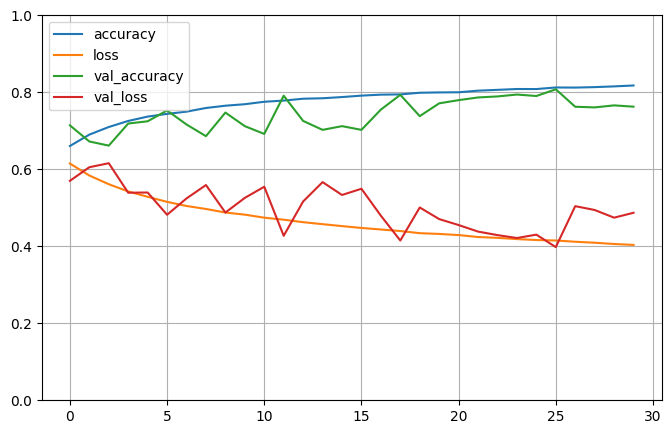

In [16]:
import matplotlib.pyplot as plt

pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.grid(True)
plt.gca().set_ylim(0, 1) # set the vertical range to [0-1]
plt.show()

In [17]:
model.evaluate(X_test, y_test)

207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 835us/step - accuracy: 0.7622 - loss: 0.4940


[0.49399739503860474, 0.76222825050354]

In [18]:
from sklearn.metrics import classification_report

y_pred = (model.predict(X_test) > 0.5).astype(int)

print(classification_report(y_test, y_pred))

207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 664us/step
              precision    recall  f1-score   support

         0.0       0.99      0.77      0.86      6507
         1.0       0.03      0.37      0.05       117

    accuracy                           0.76      6624
   macro avg       0.51      0.57      0.46      6624
weighted avg       0.97      0.76      0.85      6624



In [19]:
from sklearn.metrics import roc_auc_score

probs = model.predict(X_test)

auc = roc_auc_score(y_test, probs)

print("ROC AUC =", auc)

207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 629us/step
ROC AUC = 0.5888031166961549
